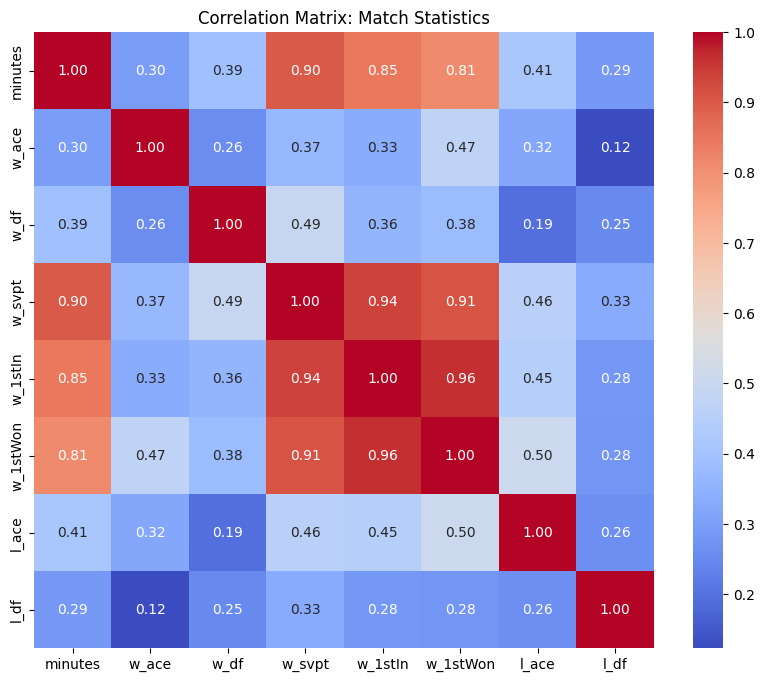

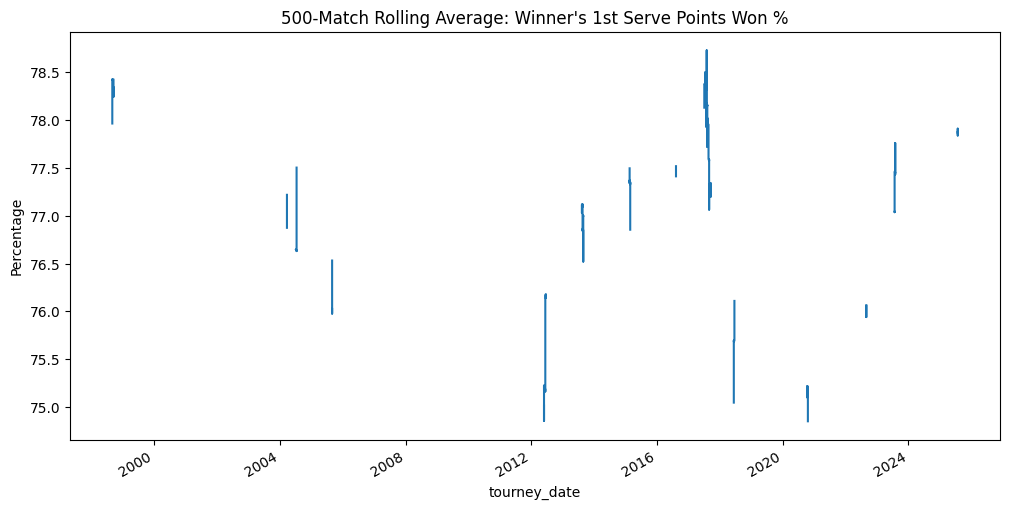

In [5]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

data_dir = 'tennis_atp-master'
all_files = glob.glob(os.path.join(data_dir, "atp_matches_*.csv"))

df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)
df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d', errors='coerce')

#Correlation Heatmap
numeric_cols = ['minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'l_ace', 'l_df']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Match Statistics")
plt.show()

# 5. Rolling Average Plot: Averages of First Serve Points Won over Time
df = df.sort_values('tourney_date')
df['w_1stWon_pct'] = (df['w_1stWon'] / df['w_1stIn']) * 100
rolling_avg = df.set_index('tourney_date')['w_1stWon_pct'].rolling(window=500).mean()

plt.figure(figsize=(12, 6))
rolling_avg.plot()
plt.title("500-Match Rolling Average: Winner's 1st Serve Points Won %")
plt.ylabel("Percentage")
plt.show()

A clear shift away from zero. If the peak is significantly positive, "Ace Difference" is a major driver of winning.

In [ ]:
# see what effect aces have
df['ace_diff'] = df['w_ace'] - df['l_ace']

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(df['ace_diff'], fill=True, color="blue", label="Ace Difference")
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Ace Difference (Winner - Loser)")
plt.xlabel("Ace Advantage")
plt.show()

: 

Tennis skill is not universal. This box plot reveals which surface-specific features are most volatile.

In [ ]:
# Filter for major surfaces
surfaces = df[df['surface'].isin(['Hard', 'Clay', 'Grass'])]

plt.figure(figsize=(12, 6))
sns.boxplot(x='surface', y='w_1stWon', data=surfaces)
plt.title("Winner's 1st Serve Points Won by Surface")
plt.show()

: 

In [ ]:
import numpy as np
# Plot tournament round vs win probability
round_map = {'F': 7, 'SF': 6, 'QF': 5, 'R16': 4, 'R32': 3, 'R64': 2, 'R128': 1}
df['round_num'] = df['round'].map(round_map)

plt.figure(figsize=(10, 6))
sns.regplot(x='round_num', y='w_1stWon', data=df, x_estimator=np.mean, lowess=True)
plt.title("Non-Linear Trend: 1st Serve Win % by Tournament Round")
plt.show()

: 

In [ ]:
# Initialize a dictionary to track current Elo for every player
ratings = {}

def get_rating(player):
    return ratings.get(player, 1500)

winner_elos = []
loser_elos = []

for _, row in df.iterrows():
    w_name, l_name = row['winner_name'], row['loser_name']
    w_elo, l_elo = get_rating(w_name), get_rating(l_name)
    
    winner_elos.append(w_elo)
    loser_elos.append(l_elo)
    
    # Update ratings (Standard K=20)
    expected_w = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
    ratings[w_name] = w_elo + 20 * (1 - expected_w)
    ratings[l_elo] = l_elo + 20 * (0 - expected_w)

df['elo_winner'] = winner_elos
df['elo_loser'] = loser_elos
df['elo_diff'] = df['elo_winner'] 0- df['elo_loser']

plt.figure(figsize=(12, 7))
sns.boxplot(x='surface', y='elo_diff', data=df)
plt.axhline(0, color='red', linestyle='--')
plt.title("Distribution of Elo Advantage by Surface")
plt.ylabel("Elo Difference (Winner - Loser)")
plt.show()

: 

Hard Courts: Exhibit the largest spread. This suggests that "upsets" (where a significantly lower-rated player wins) are more common or possible on Hard courts compared to others.

Clay/Grass: The distribution is tighter. This suggests that on these surfaces, the Elo rating is a slightly more reliable indicator of the outcome.

The Outliers: Those circles far above and below the boxes are "upsets"—matches where an extreme underdog beat an extreme favorite.
